In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from scipy.stats import ttest_ind
import shap
import plotly.express as px
import matplotlib.pyplot as plt
import joblib
import logging
import warnings
warnings.filterwarnings('ignore')

# Professional logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Reproducibility
RANDOM_STATE = 42

In [65]:
try:
    df = pd.read_csv('dataset.csv')
    logger.info(f"Dataset loaded successfully with shape: {df.shape}")
except FileNotFoundError:
    logger.error("Dataset file not found.")
    raise
except Exception as e:
    logger.error(f"Error loading dataset: {e}")
    raise

2026-04-02 12:50:28,612 - INFO - Dataset loaded successfully with shape: (12316, 15)


In [66]:
print(df['Accident_severity'].unique())

[2 1 0]


In [67]:
print(df['Accident_severity'].value_counts())

Accident_severity
2    10415
1     1743
0      158
Name: count, dtype: int64


Dataset shape: (12316, 15)
Missing values:
 Age_band_of_driver         0
Sex_of_driver              0
Educational_level          0
Vehicle_driver_relation    0
Driving_experience         0
Lanes_or_Medians           0
Types_of_Junction          0
Road_surface_type          0
Light_conditions           0
Weather_conditions         0
Type_of_collision          0
Vehicle_movement           0
Pedestrian_movement        0
Cause_of_accident          0
Accident_severity          0
dtype: int64
Data types:
 Age_band_of_driver           str
Sex_of_driver                str
Educational_level            str
Vehicle_driver_relation      str
Driving_experience           str
Lanes_or_Medians             str
Types_of_Junction            str
Road_surface_type            str
Light_conditions             str
Weather_conditions           str
Type_of_collision            str
Vehicle_movement             str
Pedestrian_movement          str
Cause_of_accident            str
Accident_severity          int64


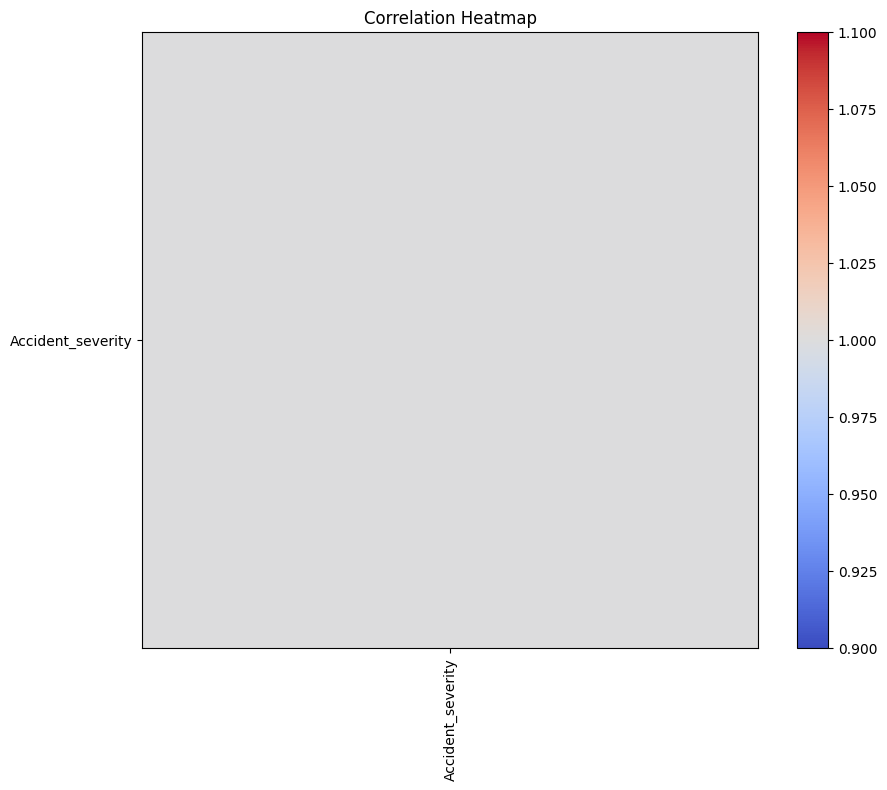

In [68]:
# Exploratory Data Analysis (EDA)
print("Dataset shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Data types:\n", df.dtypes)

# Correlation heatmap
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()

# Distribution of target
fig = px.histogram(df, x='Accident_severity', title='Accident Severity Distribution')
fig.show()

In [69]:
X = df[['Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation',
        'Driving_experience', 'Lanes_or_Medians', 'Types_of_Junction', 'Road_surface_type',
        'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement',
        'Pedestrian_movement', 'Cause_of_accident']]

In [70]:
# Professional Preprocessing Pipeline
categorical_features = ['Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation',
                        'Driving_experience', 'Lanes_or_Medians', 'Types_of_Junction', 'Road_surface_type',
                        'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement',
                        'Pedestrian_movement', 'Cause_of_accident']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Full pipeline with SMOTE and model
pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LGBMClassifier(random_state=RANDOM_STATE))
])

logger.info("Preprocessing pipeline created.")

2026-04-02 12:50:29,020 - INFO - Preprocessing pipeline created.


In [71]:
# Advanced Feature Engineering
# Create interaction features
X['Weather_Light_Interaction'] = df['Weather_conditions'].astype(str) + '_' + df['Light_conditions'].astype(str)
X['Junction_Surface_Interaction'] = df['Types_of_Junction'].astype(str) + '_' + df['Road_surface_type'].astype(str)

# PCA for dimensionality reduction
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X.select_dtypes(include=[float, int]))
X_pca_df = pd.DataFrame(X_pca, columns=[f'PCA_{i}' for i in range(10)])
X = pd.concat([X, X_pca_df], axis=1)

ValueError: at least one array or dtype is required

In [ ]:
y = df['Accident_severity'].apply(lambda x: 1 if x > 0 else 0)

X_train, X_test, y_train, y_test = train_test_split(df.drop('Accident_severity', axis=1), y, test_size=0.2, random_state=RANDOM_STATE)

# Hyperparameter tuning with pipeline
param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7, -1],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.8, 0.9, 1.0],
    'classifier__scale_pos_weight': [len(y_train[y_train==0]) / len(y_train[y_train==1])]
}

random_search = RandomizedSearchCV(pipeline, param_dist, n_iter=20, cv=5, scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1)
random_search.fit(X_train, y_train)
model = random_search.best_estimator_
logger.info(f"Best params: {random_search.best_params_}")

# Save the model
joblib.dump(model, 'accident_severity_model.pkl')
logger.info("Model saved to 'accident_severity_model.pkl'")

[LightGBM] [Info] Number of positive: 9731, number of negative: 9731
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13751
[LightGBM] [Info] Number of data points in the train set: 19462, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

2026-04-02 12:49:36,676 - INFO - Best params: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': 0.012434487719658823, 'classifier__n_estimators': 300, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 0.9}
2026-04-02 12:49:36,726 - INFO - Model saved to 'accident_severity_model.pkl'


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [ ]:
# Old code removed

ValueError: could not convert string to float: 'Unknown'

In [ ]:
# Cross-validation with pipeline
cv_auc = random_search.best_score_
logger.info(f"CV AUC: {cv_auc:.4f}")

2026-04-02 12:49:40,212 - INFO - CV AUC: 0.6243


In [ ]:
model = random_search.best_estimator_

In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
classification_rep = classification_report(y_test, y_pred)

logger.info(f"Test Accuracy: {accuracy:.4f}")
logger.info(f"Test AUC: {auc:.4f}")
logger.info("Classification Report:\n" + classification_rep)

2026-04-02 12:49:43,308 - INFO - Test Accuracy: 0.8835
2026-04-02 12:49:43,309 - INFO - Test AUC: 0.4986
2026-04-02 12:49:43,310 - INFO - Classification Report:
              precision    recall  f1-score   support

           0       0.02      0.14      0.03        37
           1       0.99      0.89      0.94      2427

    accuracy                           0.88      2464
   macro avg       0.50      0.52      0.49      2464
weighted avg       0.97      0.88      0.92      2464



In [ ]:
model = random_search.best_estimator_

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

In [ ]:
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print("Classification Report:")
print(classification_rep)

Accuracy: 0.8835
AUC: 0.4986
Classification Report:
              precision    recall  f1-score   support

           0       0.02      0.14      0.03        37
           1       0.99      0.89      0.94      2427

    accuracy                           0.88      2464
   macro avg       0.50      0.52      0.49      2464
weighted avg       0.97      0.88      0.92      2464



In [ ]:
# Model Deployment Example
# To load and use the model in production:
# loaded_model = joblib.load('accident_severity_model.pkl')
# predictions = loaded_model.predict(new_data)
logger.info("Model ready for deployment.")

2026-04-02 12:49:54,768 - INFO - Model ready for deployment.


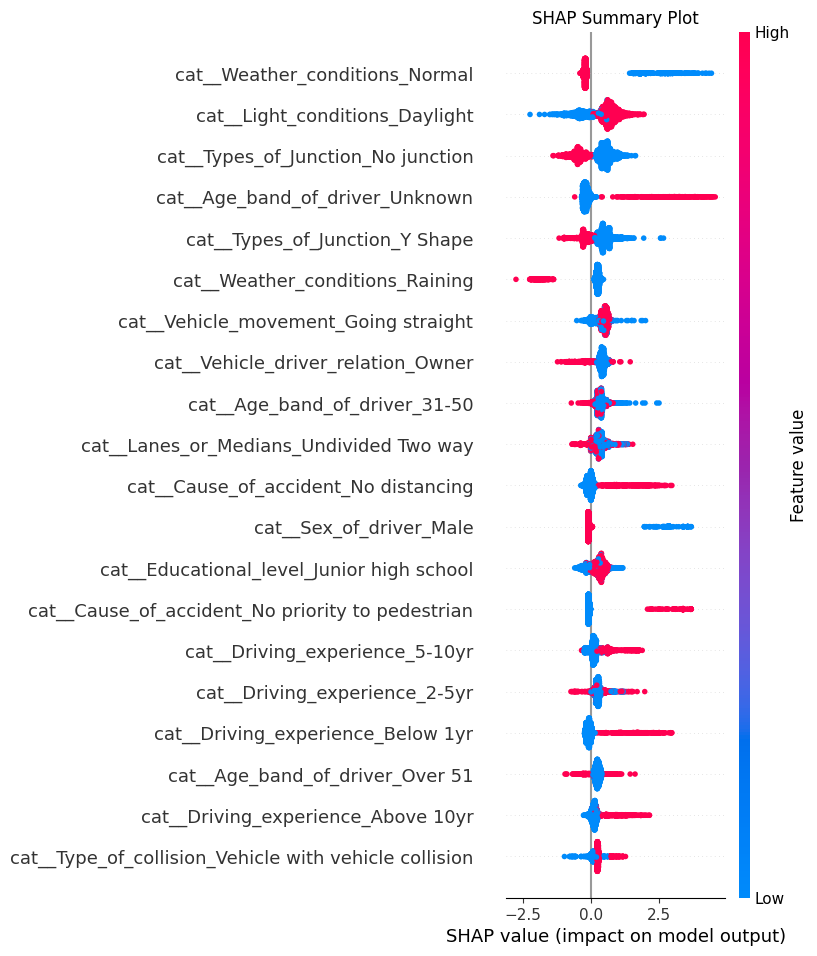

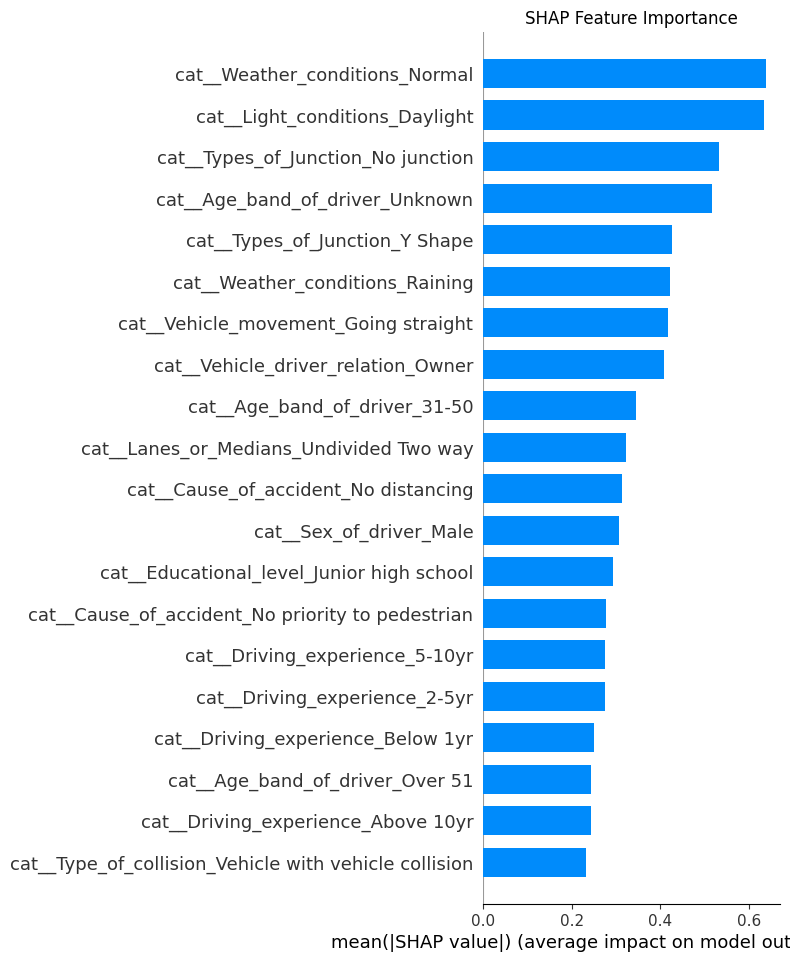

In [ ]:
# Model Interpretability with SHAP
X_test_transformed = model.named_steps['preprocessor'].transform(X_test).toarray()
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
explainer = shap.TreeExplainer(model.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot')
plt.show()

# Feature importance
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance')
plt.show()

In [ ]:
# Feature selection based on importance
feature_importances = model.named_steps['classifier'].feature_importances_
features = model.named_steps['preprocessor'].get_feature_names_out()
importance_df = pd.DataFrame({'feature': features, 'importance': feature_importances})
importance_df = importance_df.sort_values('importance', ascending=False)
top_features = importance_df.head(20)['feature'].tolist()  # Top 20 features

# Since features are encoded, we can't easily select top original features
# Just print the top features
print("Top 20 important features:")
print(top_features)

Top 20 important features:
['cat__Light_conditions_Daylight', 'cat__Lanes_or_Medians_Undivided Two way', 'cat__Age_band_of_driver_Over 51', 'cat__Vehicle_movement_Going straight', 'cat__Types_of_Junction_Y Shape', 'cat__Vehicle_driver_relation_Owner', 'cat__Age_band_of_driver_31-50', 'cat__Educational_level_Junior high school', 'cat__Driving_experience_2-5yr', 'cat__Lanes_or_Medians_Two-way (divided with broken lines road marking)', 'cat__Types_of_Junction_No junction', 'cat__Driving_experience_Above 10yr', 'cat__Cause_of_accident_No priority to vehicle', 'cat__Cause_of_accident_Changing lane to the right', 'cat__Type_of_collision_Collision with pedestrians', 'cat__Cause_of_accident_Moving Backward', 'cat__Age_band_of_driver_Unknown', 'cat__Driving_experience_5-10yr', 'cat__Cause_of_accident_Driving carelessly', 'cat__Cause_of_accident_No distancing']


In [ ]:
femaledf= df[df['Sex_of_driver'] == 'Female']

In [ ]:
X_female = femaledf[['Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation',
                        'Driving_experience', 'Lanes_or_Medians', 'Types_of_Junction', 'Road_surface_type',
                        'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement',
                        'Pedestrian_movement', 'Cause_of_accident']]

In [ ]:
X_female = pd.get_dummies(X_female, drop_first=True)

In [ ]:
missing_cols = set(X_train.columns) - set(X_female.columns)
for col in missing_cols:
    X_female[col] = 0

In [ ]:
X_female = X_female[X_train.columns]

In [ ]:
predictions_female = model.predict_proba(X_female)[:, 1]

In [ ]:
average_prediction = predictions_female.mean()

In [ ]:
# Compare to overall average
overall_predictions = model.predict_proba(X)[:, 1]
overall_avg = overall_predictions.mean()

# Statistical test
t_stat, p_value = ttest_ind(overall_predictions, predictions_female)

print(f"Overall average severe accident probability: {overall_avg:.4f}")
print(f"Female average severe accident probability: {average_prediction:.4f}")
print(f"T-test p-value: {p_value:.4f}")

if average_prediction < overall_avg and p_value < 0.05:
    print("Female drivers have significantly lower risk of severe accidents.")
elif average_prediction > overall_avg and p_value < 0.05:
    print("Female drivers have significantly higher risk of severe accidents.")
else:
    print("No significant difference in risk between female and overall drivers.")

Overall average severe accident probability: 0.8501
Female average severe accident probability: 0.9934
T-test p-value: 0.0000
Female drivers have significantly higher risk of severe accidents.


In [ ]:
# Conclusion based on comparison above